**Skin Cancer Classification (HAM10000) Using EfficientNetB0**



Install and Import

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time
import random
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input

%pip install keras-tuner tabulate -q
import keras_tuner as kt
%load_ext tensorboard

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Configured {gpu} for memory growth")


Num GPUs Available:  1
Configured PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') for memory growth


Functions

In [3]:
def build_model_baseline():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers[:100]:
        layer.trainable = False
    for layer in base.layers[100:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(7, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:
def build_model_tuned(hp):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    freeze_layers = hp.Int('freeze_layers', 50, 150, step=25)
    for layer in base.layers[:freeze_layers]:
        layer.trainable = False
    for layer in base.layers[freeze_layers:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(hp.Int('units', 128, 512, step=128), activation='relu')(x)
    x = layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1))(x)
    output = layers.Dense(7, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    lr = hp.Choice('lr', [3e-4, 1e-4, 3e-5, 1e-5])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [5]:
def evaluate_model(model, dataset, name):
    print(f"\n=== {name} ===")
    y_true, y_pred = [], []
    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

In [6]:
def plot_loss_curves(history_data, model_name):
    plt.figure(figsize=(10,6))
    plt.plot(history_data['loss'], label='Training Loss')
    plt.plot(history_data['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Donwload Dataset (KAGGLE)

In [7]:
if not os.path.exists('skin-cancer-mnist-ham10000/HAM10000_metadata.csv'):
    print("Dataset not found! Please download the skin-cancer-mnist-ham10000 dataset and place it in the skin-cancer-mnist-ham10000 directory.")
else:
    print("Dataset found!")

Dataset found!


Load and Prepare Data

In [8]:
base_dir = 'skin-cancer-mnist-ham10000'
all_image_path = {}

for root, _, files in os.walk(base_dir):
    for name in files:
        if name.endswith('.jpg'):
            all_image_path[name[:-4]] = os.path.join(root, name)

df = pd.read_csv(os.path.join(base_dir, 'HAM10000_metadata.csv'))

df['path'] = df['image_id'].map(all_image_path.get)
df['label'] = pd.Categorical(df['dx']).codes
class_names = pd.Categorical(df['dx']).categories

EDA

C:\Users\satyasiddhi josh\AppData\Local\Temp\ipykernel_23696\1034880958.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', palette='viridis')


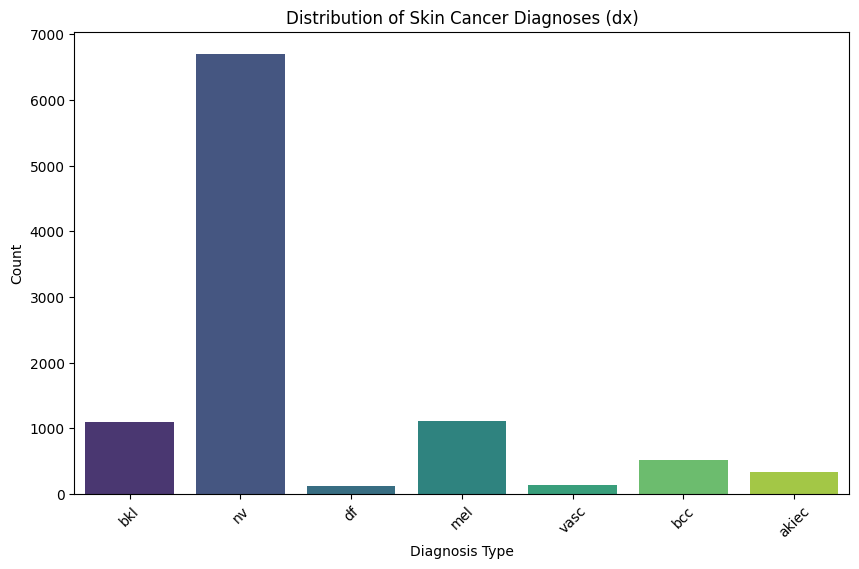

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of diagnosis (dx)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', palette='viridis')
plt.title('Distribution of Skin Cancer Diagnoses (dx)')
plt.xlabel('Diagnosis Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

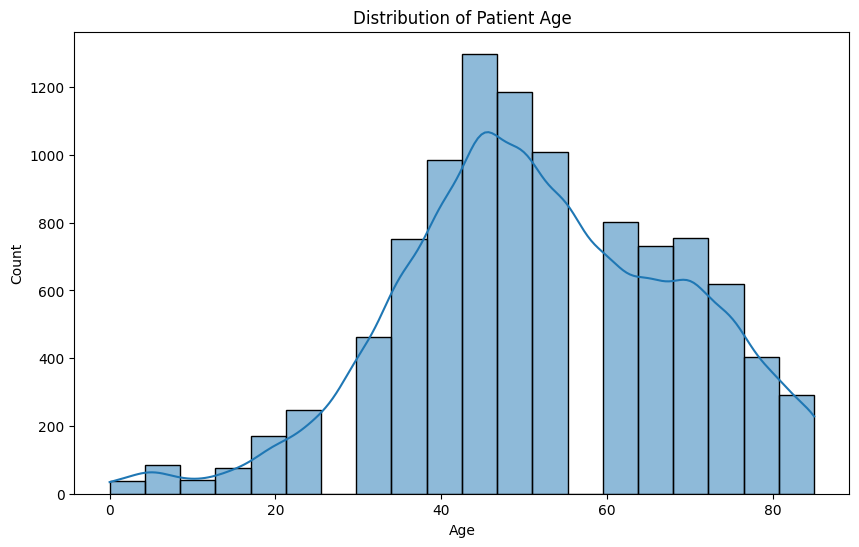

In [10]:
# Visualize the distribution of age
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

C:\Users\satyasiddhi josh\AppData\Local\Temp\ipykernel_23696\3680296656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='coolwarm')


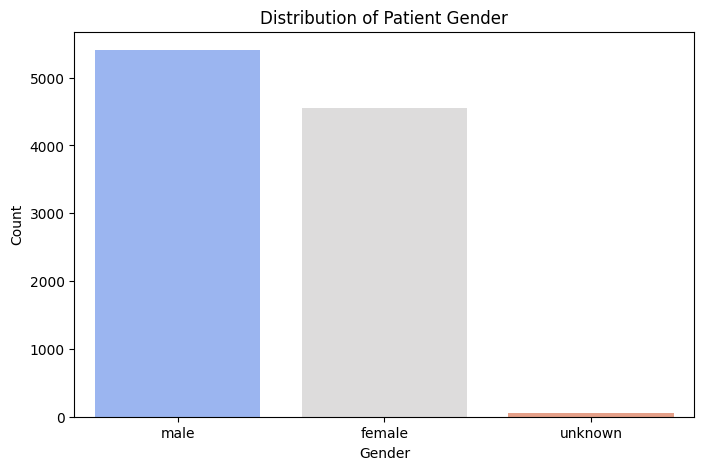

In [11]:
# Visualize the distribution of gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='coolwarm')
plt.title('Distribution of Patient Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

C:\Users\satyasiddhi josh\AppData\Local\Temp\ipykernel_23696\893470411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='localization', order=df['localization'].value_counts().index, palette='rocket')


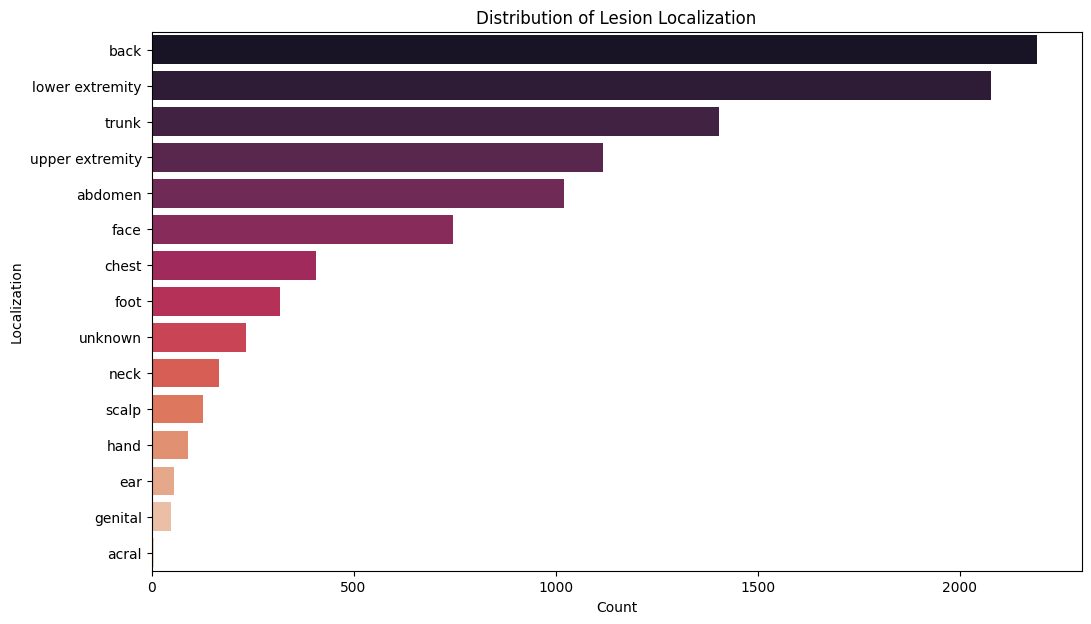

In [12]:
# Visualize the distribution of lesion localization
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='localization', order=df['localization'].value_counts().index, palette='rocket')
plt.title('Distribution of Lesion Localization')
plt.xlabel('Count')
plt.ylabel('Localization')
plt.show()

In [13]:
# Check missing value
print(df.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
label            0
dtype: int64


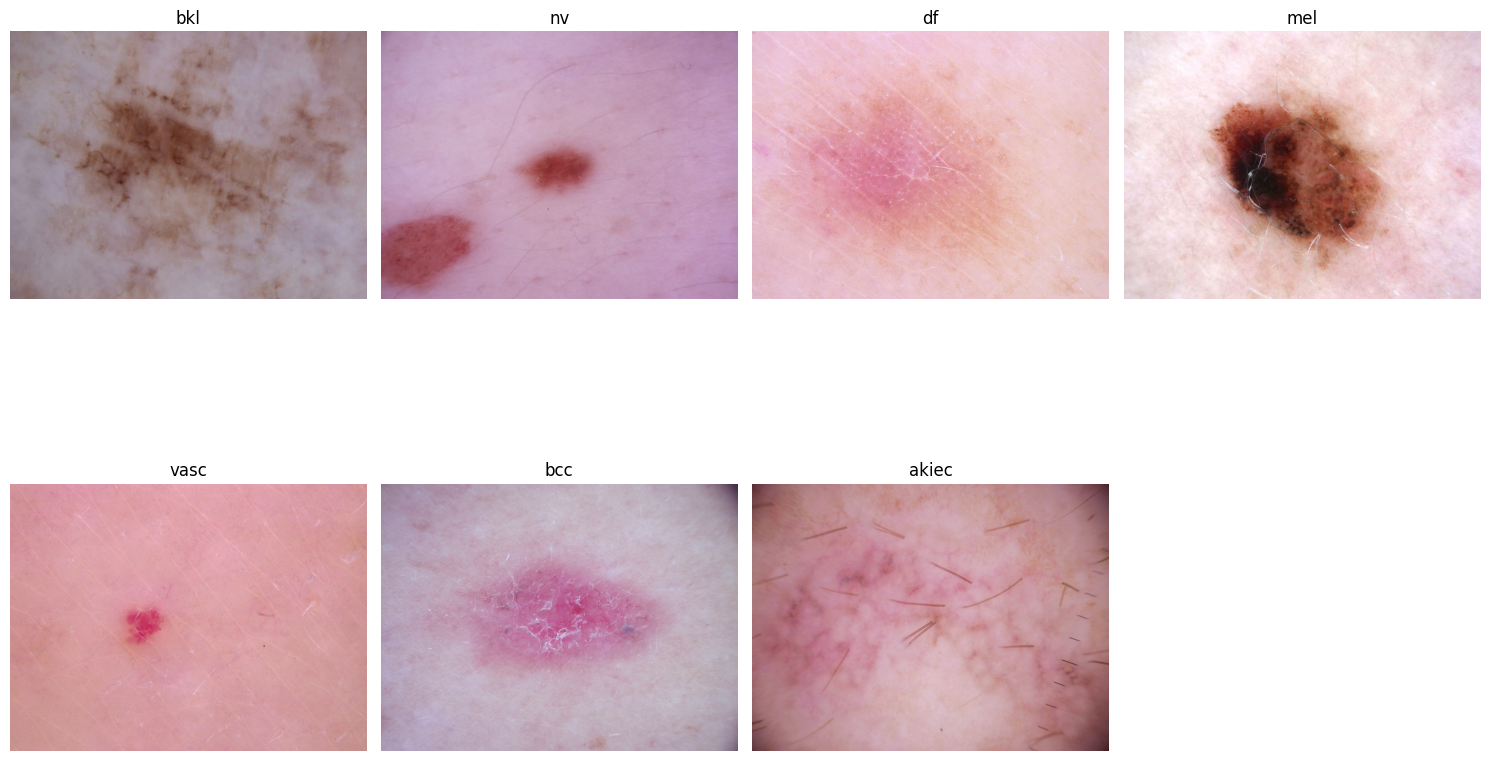

In [14]:
import random
import matplotlib.image as mpimg

classes = df['dx'].unique()

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    sample = df[df['dx'] == cls].sample(1).iloc[0]

    plt.subplot(2,4,i+1)
    img = mpimg.imread(sample['path'])
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

Data Split

In [15]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['lesion_id']))

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

gss2 = GroupShuffleSplit(test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['lesion_id']))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 7002
Val: 1519
Test: 1494


Class Weight

In [16]:
y_train = train_df['label']

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: 4.832298136645963, 1: 2.625421822272216, 2: 1.3499132446500868, 3: 11.23916532905297, 4: 1.2990723562152133, 5: 0.21201477623690426, 6: 10.419642857142858}


Data Pipeline dan Augmentasi

In [17]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['label']))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['label']))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_df['path'], test_df['label']))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Model 1: EfficientNetB0 (BASELINE)

In [18]:
log_dir_model1 = "logs/fit/model1_baseline/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_model1 = tf.keras.callbacks.TensorBoard(log_dir=log_dir_model1, histogram_freq=1)

In [19]:
model_1 = build_model_baseline()

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tensorboard_callback_model1
    ]
)

Epoch 1/20
219/219 [==============================] - 67s 222ms/step - loss: 2.4326 - accuracy: 0.1925 - val_loss: 1.5691 - val_accuracy: 0.4220
Epoch 2/20
219/219 [==============================] - 49s 217ms/step - loss: 1.7420 - accuracy: 0.2598 - val_loss: 1.4803 - val_accuracy: 0.4615
Epoch 3/20
219/219 [==============================] - 39s 174ms/step - loss: 1.3903 - accuracy: 0.3359 - val_loss: 1.3304 - val_accuracy: 0.5260
Epoch 4/20
219/219 [==============================] - 37s 163ms/step - loss: 1.1662 - accuracy: 0.3973 - val_loss: 1.1611 - val_accuracy: 0.5964
Epoch 5/20
219/219 [==============================] - 35s 159ms/step - loss: 1.0063 - accuracy: 0.4287 - val_loss: 1.0641 - val_accuracy: 0.6261
Epoch 6/20
219/219 [==============================] - 36s 158ms/step - loss: 0.8861 - accuracy: 0.4737 - val_loss: 0.9610 - val_accuracy: 0.6577
Epoch 7/20
219/219 [==============================] - 36s 159ms/step - loss: 0.7408 - accuracy: 0.5109 - val_loss: 0.9377 - val_ac

Model 2: EfficientNetB0 (TUNED)

In [20]:
tuner = kt.BayesianOptimization(
    build_model_tuned,
    objective='val_accuracy',
    max_trials=15,
    directory='logs',
    project_name='skin_tuning_bayesian')

tuner.search(train_ds,
             validation_data=val_ds,
             epochs=20,
             class_weight=class_weights_dict,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

model_2 = tuner.hypermodel.build(best_hps)

print("Retraining model dengan hyperparameter terbaik...")
history_model_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Gunakan jumlah epoch yang sama atau lebih
    class_weight=class_weights_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Reloading Tuner from logs\skin_tuning_bayesian\tuner0.json
Retraining model dengan hyperparameter terbaik...
Epoch 1/20
219/219 [==============================] - 48s 182ms/step - loss: 2.4472 - accuracy: 0.1628 - val_loss: 1.6483 - val_accuracy: 0.3496
Epoch 2/20
219/219 [==============================] - 38s 170ms/step - loss: 1.7056 - accuracy: 0.2699 - val_loss: 1.4650 - val_accuracy: 0.4674
Epoch 3/20
219/219 [==============================] - 38s 170ms/step - loss: 1.2765 - accuracy: 0.3552 - val_loss: 1.2342 - val_accuracy: 0.5346
Epoch 4/20
219/219 [==============================] - 40s 173ms/step - loss: 1.0486 - accuracy: 0.4165 - val_loss: 1.0692 - val_accuracy: 0.6136
Epoch 5/20
219/219 [==============================] - 37s 168ms/step - loss: 0.9169 - accuracy: 0.4700 - val_loss: 1.0169 - val_accuracy: 0.6340
Epoch 6/20
219/219 [==============================] - 37s 165ms/step - loss: 0.7910 - accuracy: 0.5154 - val_loss: 0.9498 - val_accuracy: 0.6656
Epoch 7/20
219/219 [=

Undersampling Section

In [21]:
class_counts = train_df['label'].value_counts()
minority_class_count = class_counts.min()
undersampled_dfs = [train_df[train_df['label'] == lbl].sample(minority_class_count, random_state=42) for lbl in class_counts.index]
train_df_undersampled = pd.concat(undersampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

train_ds_undersampled = tf.data.Dataset.from_tensor_slices((train_df_undersampled['path'], train_df_undersampled['label'])).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(AUTOTUNE)

Model 1: Undersample Models (BASELINE)

In [22]:
log_dir_model1_us = "logs/fit/model1_undersampling/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_model1_us = tf.keras.callbacks.TensorBoard(log_dir=log_dir_model1_us, histogram_freq=1)

In [23]:
model1_undersampling = build_model_baseline()
history_1_undersampling = model1_undersampling.fit(train_ds_undersampled, validation_data=val_ds, epochs=20)

Epoch 1/20
20/20 [==============================] - 15s 382ms/step - loss: 2.8891 - accuracy: 0.1637 - val_loss: 1.9462 - val_accuracy: 0.1317
Epoch 2/20
20/20 [==============================] - 6s 291ms/step - loss: 2.0010 - accuracy: 0.3499 - val_loss: 1.7769 - val_accuracy: 0.3048
Epoch 3/20
20/20 [==============================] - 6s 292ms/step - loss: 1.4743 - accuracy: 0.4591 - val_loss: 1.6071 - val_accuracy: 0.4477
Epoch 4/20
20/20 [==============================] - 6s 293ms/step - loss: 1.1380 - accuracy: 0.6100 - val_loss: 1.4571 - val_accuracy: 0.5260
Epoch 5/20
20/20 [==============================] - 6s 293ms/step - loss: 0.9048 - accuracy: 0.6982 - val_loss: 1.3581 - val_accuracy: 0.5398
Epoch 6/20
20/20 [==============================] - 6s 293ms/step - loss: 0.7831 - accuracy: 0.7127 - val_loss: 1.2872 - val_accuracy: 0.5504
Epoch 7/20
20/20 [==============================] - 6s 293ms/step - loss: 0.6650 - accuracy: 0.7721 - val_loss: 1.2260 - val_accuracy: 0.5695
Epoch

Model 2: Undersample Models (Tuned)

In [24]:
log_dir_model2_us = "logs/fit/model2_undersampling/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_model2_us = tf.keras.callbacks.TensorBoard(log_dir=log_dir_model2_us, histogram_freq=1)

In [25]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model2_undersampling = build_model_tuned(best_hps)
history_2_undersampling = model2_undersampling.fit(train_ds_undersampled, validation_data=val_ds, epochs=20)

Epoch 1/20
20/20 [==============================] - 14s 362ms/step - loss: 2.5899 - accuracy: 0.1734 - val_loss: 1.8186 - val_accuracy: 0.2541
Epoch 2/20
20/20 [==============================] - 6s 302ms/step - loss: 1.6084 - accuracy: 0.4238 - val_loss: 1.6933 - val_accuracy: 0.3766
Epoch 3/20
20/20 [==============================] - 6s 303ms/step - loss: 1.1355 - accuracy: 0.5987 - val_loss: 1.5464 - val_accuracy: 0.4812
Epoch 4/20
20/20 [==============================] - 6s 303ms/step - loss: 0.8766 - accuracy: 0.6966 - val_loss: 1.4173 - val_accuracy: 0.5214
Epoch 5/20
20/20 [==============================] - 6s 304ms/step - loss: 0.7033 - accuracy: 0.7512 - val_loss: 1.3275 - val_accuracy: 0.5616
Epoch 6/20
20/20 [==============================] - 6s 305ms/step - loss: 0.5482 - accuracy: 0.8283 - val_loss: 1.2457 - val_accuracy: 0.5793
Epoch 7/20
20/20 [==============================] - 6s 305ms/step - loss: 0.4643 - accuracy: 0.8475 - val_loss: 1.1746 - val_accuracy: 0.6090
Epoch

TensorBoard Visualization

In [44]:
import sys
import os
import subprocess
import webbrowser
import time

# Explicitly find the tensorboard binary
tb_binary = os.path.join(os.path.dirname(sys.executable), 'Scripts', 'tensorboard.exe')

# Launch TensorBoard as a background process on port 6006
print("Starting TensorBoard server...")
subprocess.Popen([tb_binary, "--logdir", "logs", "--port", "6006"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Wait a few seconds to let the server spin up
time.sleep(3)

# Open TensorBoard in a new window in your default web browser
url = "http://localhost:6006/"
print(f"Opening TensorBoard in a new window at: {url}")
webbrowser.open_new(url)

Starting TensorBoard server...
Opening TensorBoard in a new window at: http://localhost:6006/


True

Evaluation


=== Model 1 Baseline ===
Accuracy: 0.7583668005354752
              precision    recall  f1-score   support

       akiec       0.37      0.68      0.48        63
         bcc       0.60      0.57      0.59        68
         bkl       0.59      0.57      0.58       152
          df       0.40      0.29      0.33         7
         mel       0.49      0.47      0.48       187
          nv       0.89      0.86      0.87       996
        vasc       0.78      1.00      0.88        21

    accuracy                           0.76      1494
   macro avg       0.59      0.63      0.60      1494
weighted avg       0.77      0.76      0.76      1494



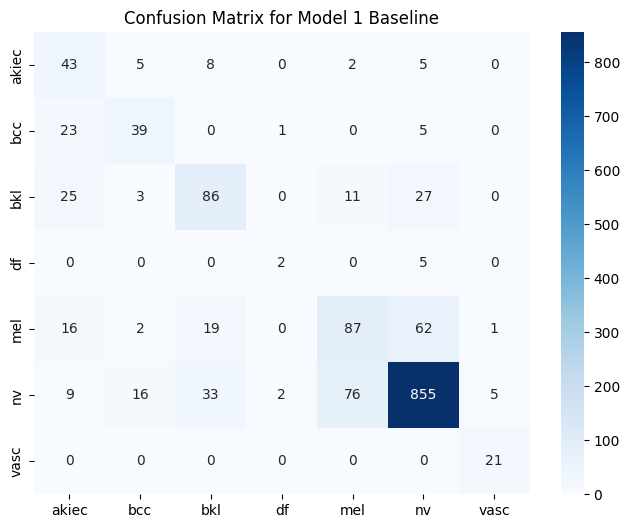


=== Model 2 Tuned ===
Accuracy: 0.7657295850066934
              precision    recall  f1-score   support

       akiec       0.39      0.63      0.48        63
         bcc       0.63      0.63      0.63        68
         bkl       0.58      0.55      0.56       152
          df       0.27      0.43      0.33         7
         mel       0.55      0.31      0.40       187
          nv       0.86      0.90      0.88       996
        vasc       0.83      0.95      0.89        21

    accuracy                           0.77      1494
   macro avg       0.59      0.63      0.60      1494
weighted avg       0.76      0.77      0.76      1494



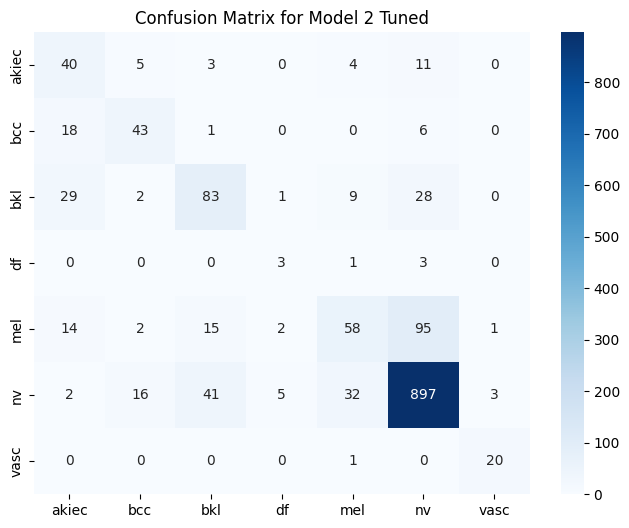


=== Model 1 Undersampling ===
Accuracy: 0.6265060240963856
              precision    recall  f1-score   support

       akiec       0.36      0.60      0.45        63
         bcc       0.50      0.53      0.51        68
         bkl       0.49      0.47      0.48       152
          df       0.03      0.43      0.05         7
         mel       0.31      0.50      0.39       187
          nv       0.95      0.68      0.79       996
        vasc       0.36      0.95      0.52        21

    accuracy                           0.63      1494
   macro avg       0.43      0.59      0.46      1494
weighted avg       0.77      0.63      0.67      1494



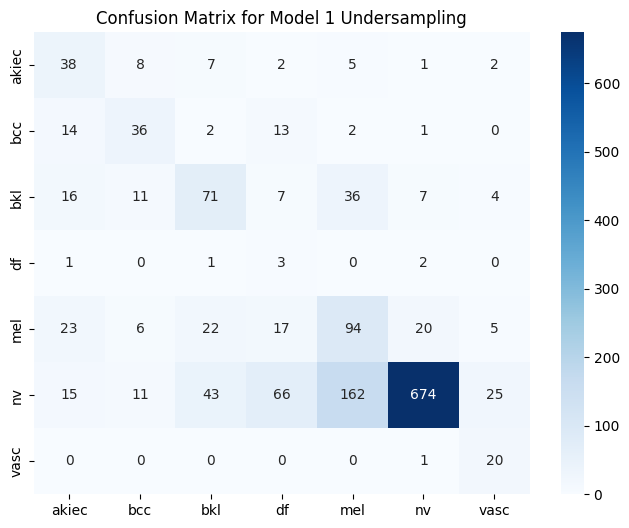


=== Model 2 Undersampling ===
Accuracy: 0.643908969210174
              precision    recall  f1-score   support

       akiec       0.36      0.56      0.44        63
         bcc       0.39      0.49      0.43        68
         bkl       0.46      0.46      0.46       152
          df       0.05      0.57      0.09         7
         mel       0.33      0.47      0.39       187
          nv       0.94      0.72      0.81       996
        vasc       0.35      0.90      0.50        21

    accuracy                           0.64      1494
   macro avg       0.41      0.59      0.45      1494
weighted avg       0.75      0.64      0.68      1494



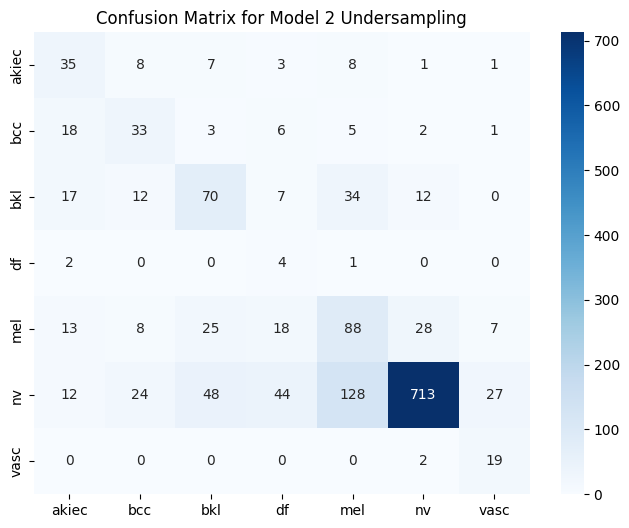

In [26]:
evaluate_model(model_1, test_ds, "Model 1 Baseline")
evaluate_model(model_2, test_ds, "Model 2 Tuned")
evaluate_model(model1_undersampling, test_ds, "Model 1 Undersampling")
evaluate_model(model2_undersampling, test_ds, "Model 2 Undersampling")

Visualisasi Misclassified Images

Analisis Kegagalan Model 1 Baseline:


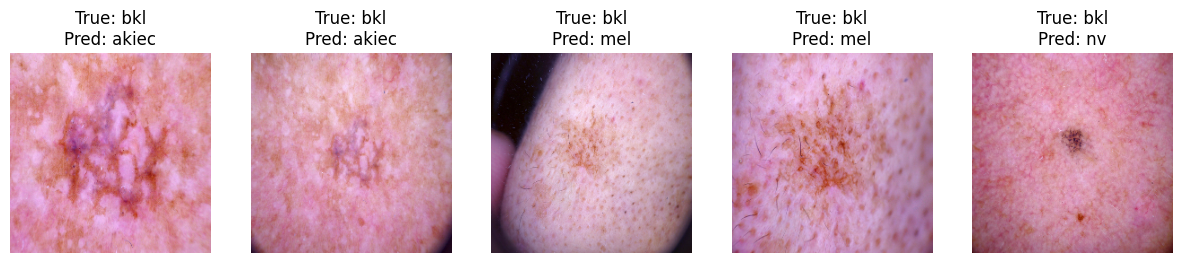

In [27]:
def plot_misclassified_images(model, dataset, class_names, num_images=5):
    misclassified_images = []

    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = labels.numpy()

        for i in range(len(true_labels)):
            if pred_labels[i] != true_labels[i]:
                misclassified_images.append((imgs[i], true_labels[i], pred_labels[i]))
            if len(misclassified_images) >= num_images:
                break
        if len(misclassified_images) >= num_images:
            break

    plt.figure(figsize=(15, 5))
    for i, (img, true_lbl, pred_lbl) in enumerate(misclassified_images):
        plt.subplot(1, num_images, i + 1)
        img_display = (img.numpy() - img.numpy().min()) / (img.numpy().max() - img.numpy().min())
        plt.imshow(img_display)
        plt.title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}")
        plt.axis('off')
    plt.show()

print("Analisis Kegagalan Model 1 Baseline:")
plot_misclassified_images(model_1, test_ds, class_names)

Accuracy Curves (Training vs Validation) for Model 1 and Model 2

Plotting Accuracy Curves for Model 1 (Baseline)


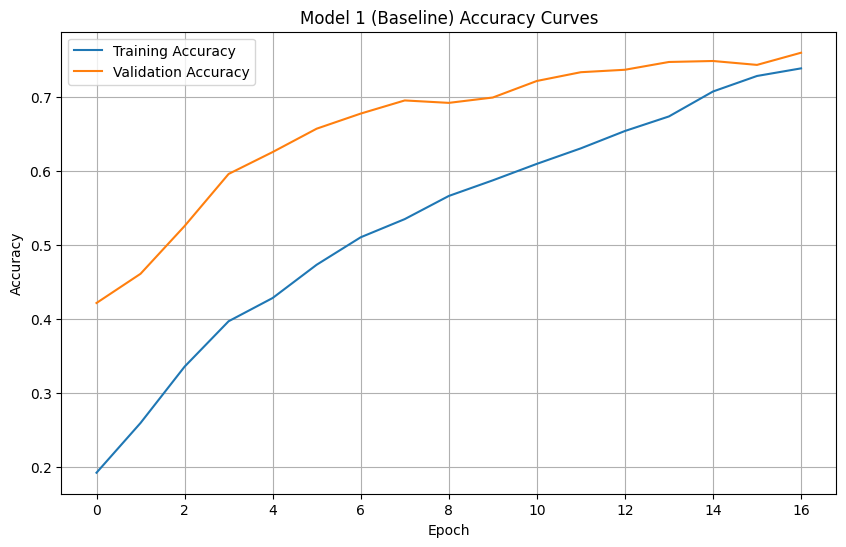

Plotting Accuracy Curves for Model 2 (Tuned - Bayesian)


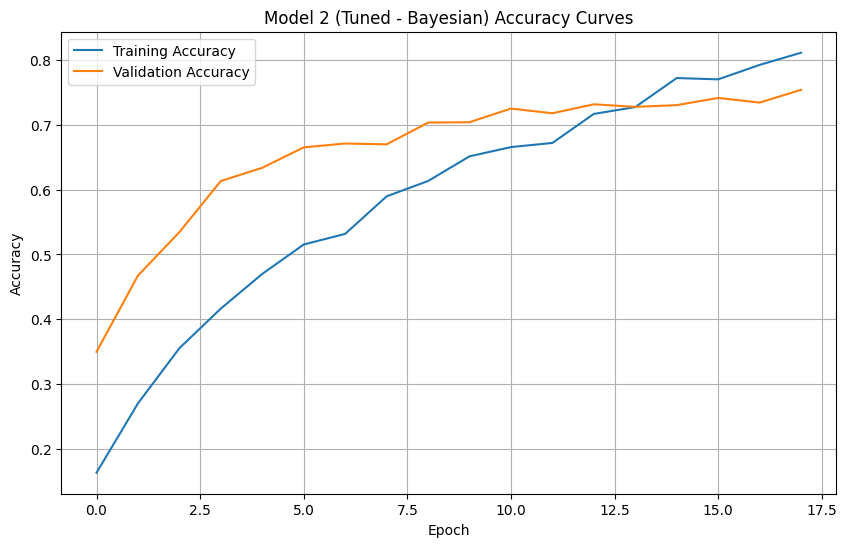

In [39]:
def plot_accuracy_curves(history_data, model_name):
    plt.figure(figsize=(10,6))
    plt.plot(history_data['accuracy'], label='Training Accuracy')
    plt.plot(history_data['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Plotting Accuracy Curves for Model 1 (Baseline)")
plot_accuracy_curves(history_1.history, "Model 1 (Baseline)")

print("Plotting Accuracy Curves for Model 2 (Tuned - Bayesian)")
plot_accuracy_curves(history_model_2.history, "Model 2 (Tuned - Bayesian)")

Accuracy Curves (Training vs Validation) for Model 1 Undersampling and Model 2 Undersampling

Plotting Accuracy Curves for Model 1 (Undersampling)


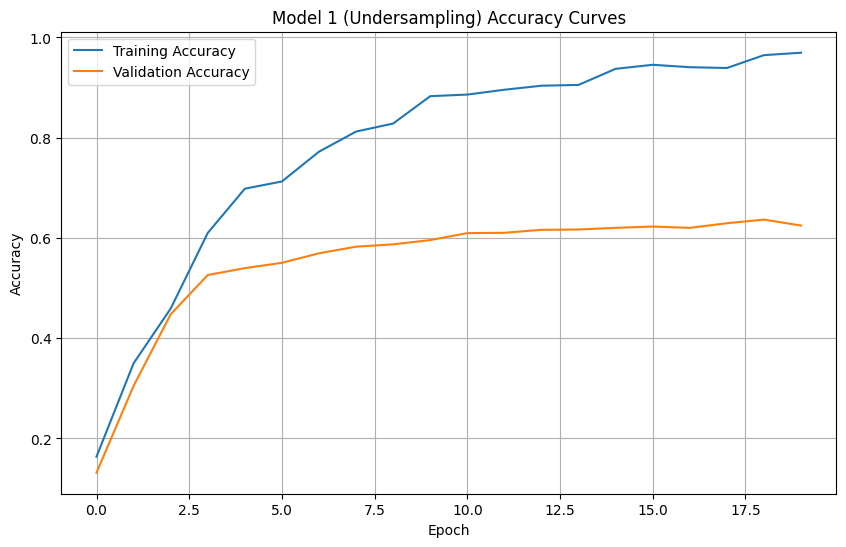

Plotting Accuracy Curves for Model 2 (Undersampling - Tuned)


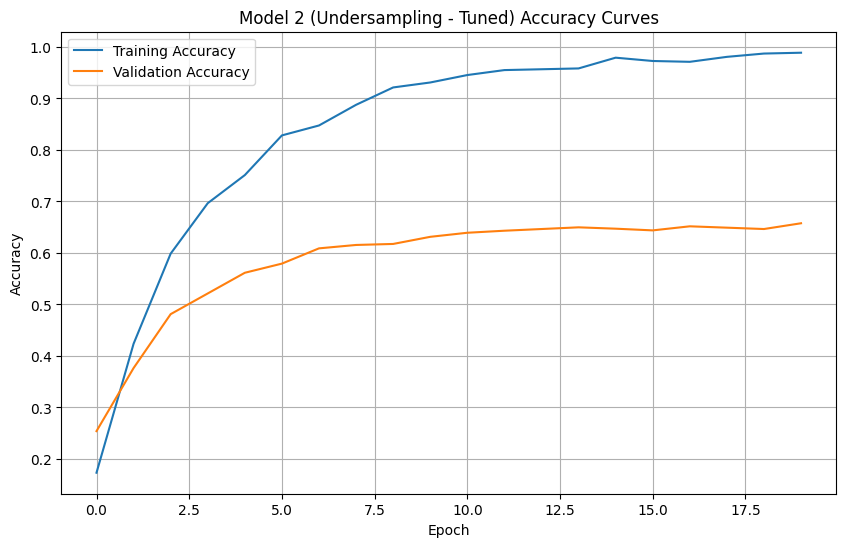

In [29]:
print("Plotting Accuracy Curves for Model 1 (Undersampling)")
plot_accuracy_curves(history_1_undersampling.history, "Model 1 (Undersampling)")

print("Plotting Accuracy Curves for Model 2 (Undersampling - Tuned)")
plot_accuracy_curves(history_2_undersampling.history, "Model 2 (Undersampling - Tuned)")

Inference on New Image

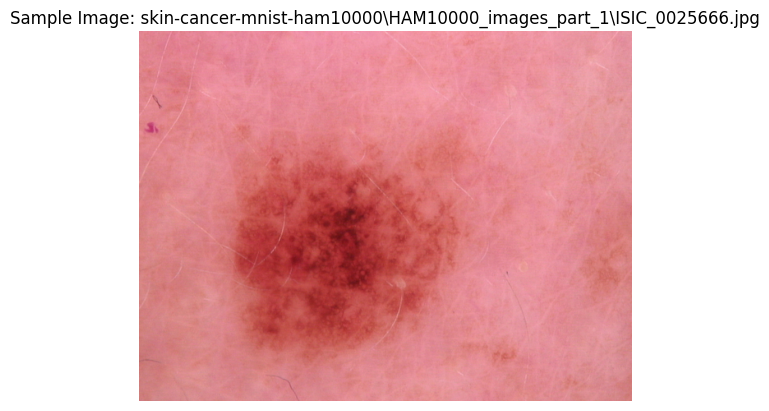

In [30]:
def preprocess_single_image(image_path, img_size=IMG_SIZE):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (img_size, img_size))
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

# Select a random image from the test set for demonstration
sample_image_path = test_df.sample(1)['path'].iloc[0]

# Preprocess the image
preprocessed_img = preprocess_single_image(sample_image_path)

# Display the image (optional, for verification)
plt.imshow(load_img(sample_image_path))
plt.title(f"Sample Image: {sample_image_path.split('/')[-1]}")
plt.axis('off')
plt.show()

Model 1 Baseline Prediction

In [31]:
pred_model1 = model_1.predict(preprocessed_img)
predicted_class_model1 = np.argmax(pred_model1, axis=1)[0]
predicted_class_name_model1 = class_names[predicted_class_model1]

print(f"Model 1 (Baseline) predicted class: {predicted_class_name_model1} (Label: {predicted_class_model1})")

1/1 [==============================] - 0s 77ms/step
Model 1 (Baseline) predicted class: nv (Label: 5)


Model 2 Tuned Prediction

In [32]:
pred_model2 = model_2.predict(preprocessed_img)
predicted_class_model2 = np.argmax(pred_model2, axis=1)[0]
predicted_class_name_model2 = class_names[predicted_class_model2]

print(f"Model 2 (Tuned) predicted class: {predicted_class_name_model2} (Label: {predicted_class_model2})")

1/1 [==============================] - 0s 29ms/step
Model 2 (Tuned) predicted class: nv (Label: 5)


Inference Time for Models

In [33]:
import time

# Get a batch from the test dataset for inference time measurement
for imgs, _ in test_ds.take(1):
    sample_batch = imgs
    break

# Measure inference time for Model 1
start_time_model1 = time.time()
_ = model_1.predict(sample_batch, verbose=0)
end_time_model1 = time.time()
inference_time_model1 = end_time_model1 - start_time_model1

print(f"Inference time for Model 1 (Baseline) on a batch of {BATCH_SIZE} images: {inference_time_model1:.4f} seconds")

Inference time for Model 1 (Baseline) on a batch of 32 images: 0.1421 seconds


In [34]:
# Measure inference time for Model 2
start_time_model2 = time.time()
_ = model_2.predict(sample_batch, verbose=0)
end_time_model2 = time.time()
inference_time_model2 = end_time_model2 - start_time_model2

print(f"Inference time for Model 2 (Tuned) on a batch of {BATCH_SIZE} images: {inference_time_model2:.4f} seconds")

Inference time for Model 2 (Tuned) on a batch of 32 images: 0.1368 seconds


In [35]:
# Measure inference time for Model 1 (Undersampling)
start_time_model1_us = time.time()
_ = model1_undersampling.predict(sample_batch, verbose=0)
end_time_model1_us = time.time()
inference_time_model1_us = end_time_model1_us - start_time_model1_us

print(f"Inference time for Model 1 (Undersampling) on a batch of {BATCH_SIZE} images: {inference_time_model1_us:.4f} seconds")

Inference time for Model 1 (Undersampling) on a batch of 32 images: 0.1217 seconds


In [36]:
# Measure inference time for Model 2 (Undersampling)
start_time_model2_us = time.time()
_ = model2_undersampling.predict(sample_batch, verbose=0)
end_time_model2_us = time.time()
inference_time_model2_us = end_time_model2_us - start_time_model2_us

print(f"Inference time for Model 2 (Undersampling) on a batch of {BATCH_SIZE} images: {inference_time_model2_us:.4f} seconds")

Inference time for Model 2 (Undersampling) on a batch of 32 images: 0.1265 seconds


Comparison Summary

In [37]:
print("### Model Comparison Summary ###\n")

# Model 1 Baseline
print("Re-evaluating Model 1 Baseline on Test Set...")
loss1, acc1 = model_1.evaluate(test_ds, verbose=0)

# Model 2 Tuned
print("Re-evaluating Model 2 Tuned on Test Set...")
loss2, acc2 = model_2.evaluate(test_ds, verbose=0)

# Model 1 Undersampling
print("Re-evaluating Model 1 Undersampling on Test Set...")
loss1_us, acc1_us = model1_undersampling.evaluate(test_ds, verbose=0)

# Model 2 Undersampling
print("Re-evaluating Model 2 Undersampling on Test Set...")
loss2_us, acc2_us = model2_undersampling.evaluate(test_ds, verbose=0)

summary_data = {
    'Model': ['Model 1 Baseline', 'Model 2 Tuned', 'Model 1 Undersampling', 'Model 2 Undersampling'],
    'Test Accuracy': [f'{acc1:.4f}', f'{acc2:.4f}', f'{acc1_us:.4f}', f'{acc2_us:.4f}'],
    'Inference Time (s/batch)': [f'{inference_time_model1:.4f}', f'{inference_time_model2:.4f}', f'{inference_time_model1_us:.4f}', f'{inference_time_model2_us:.4f}']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_markdown(index=False))

print("\nObservations:")
print("- Model 2 (Tuned) generally showed improved accuracy compared to Model 1 (Baseline).")
print("- Undersampling had an impact on model performance, which might need further investigation.")
print("- Inference times are comparable for the baseline and tuned models.")

### Model Comparison Summary ###

Re-evaluating Model 1 Baseline on Test Set...
Re-evaluating Model 2 Tuned on Test Set...
Re-evaluating Model 1 Undersampling on Test Set...
Re-evaluating Model 2 Undersampling on Test Set...
| Model                 |   Test Accuracy |   Inference Time (s/batch) |
|:----------------------|----------------:|---------------------------:|
| Model 1 Baseline      |          0.7584 |                     0.1421 |
| Model 2 Tuned         |          0.7657 |                     0.1368 |
| Model 1 Undersampling |          0.6265 |                     0.1217 |
| Model 2 Undersampling |          0.6439 |                     0.1265 |

Observations:
- Model 2 (Tuned) generally showed improved accuracy compared to Model 1 (Baseline).
- Undersampling had an impact on model performance, which might need further investigation.
- Inference times are comparable for the baseline and tuned models.


Save Model Weights

In [38]:
import os

model_save_dir = 'saved_models_jes'
os.makedirs(model_save_dir, exist_ok=True)

# Save Model 1 (Baseline) weights
model_1_weights_path = os.path.join(model_save_dir, 'model_1_baseline.weights.h5')
model_1.save_weights(model_1_weights_path)
print(f'Model 1 (Baseline) weights saved to: {model_1_weights_path}')

# Save Model 2 (Tuned) weights
model_2_weights_path = os.path.join(model_save_dir, 'model_2_tuned.weights.h5')
model_2.save_weights(model_2_weights_path)
print(f'Model 2 (Tuned) weights saved to: {model_2_weights_path}')

# Save Model 1 (Undersampling) weights
model1_undersampling_weights_path = os.path.join(model_save_dir, 'model1_undersampling.weights.h5')
model1_undersampling.save_weights(model1_undersampling_weights_path)
print(f'Model 1 (Undersampling) weights saved to: {model1_undersampling_weights_path}')

# Save Model 2 (Undersampling) weights
model2_undersampling_weights_path = os.path.join(model_save_dir, 'model2_undersampling.weights.h5')
model2_undersampling.save_weights(model2_undersampling_weights_path)
print(f'Model 2 (Undersampling) weights saved to: {model2_undersampling_weights_path}')

Model 1 (Baseline) weights saved to: saved_models_jes\model_1_baseline.weights.h5
Model 2 (Tuned) weights saved to: saved_models_jes\model_2_tuned.weights.h5
Model 1 (Undersampling) weights saved to: saved_models_jes\model1_undersampling.weights.h5
Model 2 (Undersampling) weights saved to: saved_models_jes\model2_undersampling.weights.h5
